In [1]:
import os
import sys
import json
import random
import math
import gc
import time

import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

In [2]:
# =========================================================
# CONFIG — edit paths to match your layout
# =========================================================
PROJECT_ROOT = os.path.abspath(os.path.join("..", ".."))
SPECTRAL_MODULE_DIR = os.path.join(PROJECT_ROOT, "Data Analysis")
if SPECTRAL_MODULE_DIR not in sys.path:
    sys.path.insert(0, SPECTRAL_MODULE_DIR)
import spectral_analysis as sa

IMAGES_DIR = os.path.join(PROJECT_ROOT, "Data Analytics", "Annotation", "Solar Images", "images", "default")
ANNOTATIONS_JSON = os.path.join(
    PROJECT_ROOT, "Data Analytics", "Annotation", "Solar Images", "annotations", "merged_instances_default.json"
)

# <-- ONLY CHANGE FROM YOUR UNET++ CELL 2: folder name for this model
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "Segmentation with Annotation", "Attention UNET with Shadow Filter", "outputs")
MODEL_SAVE_DIR = os.path.join(OUTPUT_DIR, "models")
METRICS_DIR = os.path.join(OUTPUT_DIR, "metrics")
PLOTS_DIR = os.path.join(OUTPUT_DIR, "plots")
PREDICTIONS_DIR = os.path.join(OUTPUT_DIR, "predictions")
for d in [MODEL_SAVE_DIR, METRICS_DIR, PLOTS_DIR, PREDICTIONS_DIR]:
    os.makedirs(d, exist_ok=True)

IMG_SIZE = 256
NUM_CLASSES = 2
CLASS_NAMES = ["background", "hassolar"]
FOREGROUND_CLASS = 1
IGNORE_INDEX = None

BATCH_SIZE = 8
LEARNING_RATE = 1e-4
EPOCHS = 50

TRAIN_FRAC, VAL_FRAC, TEST_FRAC = 0.70, 0.15, 0.15
SEED = 42

# Shadow Processing Parameters
SHADOW_DETECTOR = "local_contrast"   # "local_contrast" | "global_threshold"
SHADOW_WEIGHT = 1.5                   # Loss weight on shadow regions (lowered from 2.0 due to local contrast accuracy)
LOCAL_CONTRAST_WINDOW = 25
LOCAL_CONTRAST_K = 0.6

# Instance post-processing
PROB_THRESHOLD = 0.5
MIN_INSTANCE_AREA = 8
IOU_THRESHOLDS = (0.50, 0.95)

# --- NEW: Attention U-Net doesn't exist in segmentation_models_pytorch, so it's
# built from scratch below. BASE_CHANNELS controls its width (paper default is 64;
# lowered to 32 here given the earlier 7.6GB OOM at a larger model+resolution).
# Raise to 64 if your GPU has headroom at IMG_SIZE=256, BATCH_SIZE=8.
BASE_CHANNELS = 32

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"

if not os.path.isfile(ANNOTATIONS_JSON):
    raise FileNotFoundError(f"Could not find annotation json at: {ANNOTATIONS_JSON}")
if not os.path.isdir(IMAGES_DIR):
    raise FileNotFoundError(f"Could not find images directory at: {IMAGES_DIR}")

print("Device:", DEVICE)
print("Images dir:", IMAGES_DIR)
print("Annotations json:", ANNOTATIONS_JSON)
print("Spectral module:", sa.__file__)
print("Shadow Detector Selected:", SHADOW_DETECTOR)
print("Base channels:", BASE_CHANNELS)
print("Outputs will be saved under:", OUTPUT_DIR)

Device: cuda
Images dir: /mnt/New_Volume/Projects/Solar Detection/Data Analytics/Annotation/Solar Images/images/default
Annotations json: /mnt/New_Volume/Projects/Solar Detection/Data Analytics/Annotation/Solar Images/annotations/merged_instances_default.json
Spectral module: /mnt/New_Volume/Projects/Solar Detection/Data Analysis/spectral_analysis.py
Shadow Detector Selected: local_contrast
Base channels: 32
Outputs will be saved under: /mnt/New_Volume/Projects/Solar Detection/Segmentation with Annotation/Attention UNET with Shadow Filter/outputs


In [3]:
with open(ANNOTATIONS_JSON, "r") as f:
    coco = json.load(f)

images_by_id = {img["id"]: img for img in coco["images"]}
anns_by_image_id = {}
for ann in coco["annotations"]:
    anns_by_image_id.setdefault(ann["image_id"], []).append(ann)

all_ids = sorted(images_by_id.keys())
random.Random(SEED).shuffle(all_ids)

n_val = int(len(all_ids) * VAL_FRAC)
n_test = int(len(all_ids) * TEST_FRAC)
val_ids = all_ids[:n_val]
test_ids = all_ids[n_val:n_val + n_test]
train_ids = all_ids[n_val + n_test:]

split_path = os.path.join(OUTPUT_DIR, "split.json")
with open(split_path, "w") as f:
    json.dump({"train": train_ids, "val": val_ids, "test": test_ids}, f)

print(f"Total: {len(all_ids)} | train: {len(train_ids)} | val: {len(val_ids)} | test: {len(test_ids)}")
print("Split saved to", split_path)


def load_image_and_mask(image_id):
    info = images_by_id[image_id]
    img_path = os.path.join(IMAGES_DIR, info["file_name"])
    bgr = cv2.imread(img_path, cv2.IMREAD_COLOR)
    if bgr is None:
        raise FileNotFoundError(f"Could not read image: {img_path}")
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    h, w = rgb.shape[:2]

    gt = np.zeros((h, w), dtype=np.uint8)
    for ann in anns_by_image_id.get(image_id, []):
        seg = ann.get("segmentation")
        if isinstance(seg, list):
            for poly in seg:
                pts = np.round(np.array(poly, dtype=np.float32).reshape(-1, 2)).astype(np.int32)
                cv2.fillPoly(gt, [pts], 1)
    return rgb, gt

Total: 2500 | train: 1750 | val: 375 | test: 375
Split saved to /mnt/New_Volume/Projects/Solar Detection/Segmentation with Annotation/Attention UNET with Shadow Filter/outputs/split.json


In [4]:
def get_shadow_mask(rgb):
    if SHADOW_DETECTOR == "local_contrast":
        return sa.detect_shadow_local_contrast(rgb, window=LOCAL_CONTRAST_WINDOW, k=LOCAL_CONTRAST_K)
    return sa.detect_shadow_mask(rgb, k=sa.SpectralConfig().shadow_y_k)


def synthetic_shadow_on_panel(rgb, gt, darken=(0.45, 0.75), blue_shift=1.15):
    ys, xs = np.where(gt == 1)
    if len(ys) == 0:
        return rgb
    idx = np.random.randint(len(ys))
    cy, cx = int(ys[idx]), int(xs[idx])
    h, w = rgb.shape[:2]
    rad_y = np.random.randint(max(4, h // 30), max(6, h // 8))
    rad_x = np.random.randint(max(4, w // 30), max(6, w // 8))
    patch = np.zeros((h, w), dtype=np.uint8)
    cv2.ellipse(patch, (cx, cy), (rad_x, rad_y), 0, 0, 360, 1, thickness=-1)
    out = rgb.astype(np.float32)
    f = np.random.uniform(*darken)
    out[patch == 1, 0] *= f
    out[patch == 1, 1] *= f
    out[patch == 1, 2] *= min(f * blue_shift, 1.0)
    return np.clip(out, 0, 255).astype(np.uint8)


def random_geometric(rgb, gt):
    if np.random.rand() < 0.5:
        rgb, gt = rgb[:, ::-1], gt[:, ::-1]
    if np.random.rand() < 0.5:
        rgb, gt = rgb[::-1], gt[::-1]
    k = np.random.randint(4)
    if k:
        rgb, gt = np.rot90(rgb, k), np.rot90(gt, k)
    return np.ascontiguousarray(rgb), np.ascontiguousarray(gt)


IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)


class SolarShadowDataset(Dataset):
    def __init__(self, sample_ids, img_size, augment=False, shadow_augment_prob=0.5):
        self.sample_ids = list(sample_ids)
        self.img_size = img_size
        self.augment = augment
        self.shadow_augment_prob = shadow_augment_prob

    def __len__(self):
        return len(self.sample_ids)

    def __getitem__(self, idx):
        image_id = self.sample_ids[idx]
        rgb, gt = load_image_and_mask(image_id)
        rgb = cv2.resize(rgb, (self.img_size, self.img_size), interpolation=cv2.INTER_AREA)
        gt = cv2.resize(gt, (self.img_size, self.img_size), interpolation=cv2.INTER_NEAREST)

        if self.augment:
            rgb, gt = random_geometric(rgb, gt)
            if gt.sum() > 0 and np.random.rand() < self.shadow_augment_prob:
                rgb = synthetic_shadow_on_panel(rgb, gt)

        shadow = get_shadow_mask(rgb)
        corrected = sa.remove_shadow_linear(rgb, shadow) if shadow.sum() > 0 else rgb

        rgb_norm = (corrected.astype(np.float32) / 255.0 - IMAGENET_MEAN) / IMAGENET_STD
        stacked = np.dstack([rgb_norm, shadow.astype(np.float32)])

        image_t = torch.from_numpy(np.ascontiguousarray(stacked.transpose(2, 0, 1))).float()
        mask_t = torch.from_numpy(gt.astype(np.int64))           # long, for CrossEntropyLoss
        shadow_t = torch.from_numpy(shadow.astype(np.float32))
        return image_t, mask_t, shadow_t

In [5]:
train_ds = SolarShadowDataset(train_ids, IMG_SIZE, augment=True)
val_ds = SolarShadowDataset(val_ids, IMG_SIZE, augment=False)
test_ds = SolarShadowDataset(test_ids, IMG_SIZE, augment=False)
train_eval_ds = SolarShadowDataset(train_ids, IMG_SIZE, augment=False)  # clean train metrics, no aug

def make_loader(ds, batch_size, shuffle, drop_last=False):
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=2,
                      pin_memory=(DEVICE.type == "cuda"), drop_last=drop_last)

train_loader = make_loader(train_ds, BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = make_loader(val_ds, BATCH_SIZE, shuffle=False)
test_loader = make_loader(test_ds, BATCH_SIZE, shuffle=False)
train_eval_loader = make_loader(train_eval_ds, BATCH_SIZE, shuffle=False)

print(f"Batches — train: {len(train_loader)} | val: {len(val_loader)} | test: {len(test_loader)}")

Batches — train: 218 | val: 47 | test: 47


In [6]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)


class UpConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True),
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.up(x)


class AttentionGate(nn.Module):
    def __init__(self, gate_ch, skip_ch, inter_ch):
        super().__init__()
        self.W_gate = nn.Sequential(nn.Conv2d(gate_ch, inter_ch, 1), nn.BatchNorm2d(inter_ch))
        self.W_skip = nn.Sequential(nn.Conv2d(skip_ch, inter_ch, 1), nn.BatchNorm2d(inter_ch))
        self.psi = nn.Sequential(nn.Conv2d(inter_ch, 1, 1), nn.BatchNorm2d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)

    def forward(self, gate, skip):
        g = self.W_gate(gate)
        s = self.W_skip(skip)
        if g.shape[2:] != s.shape[2:]:
            g = F.interpolate(g, size=s.shape[2:], mode="bilinear", align_corners=True)
        att = self.psi(self.relu(g + s))
        return skip * att


class AttentionUNet(nn.Module):
    def __init__(self, in_channels=4, num_classes=2, base_ch=32):
        super().__init__()
        c1, c2, c3, c4, c5 = base_ch, base_ch*2, base_ch*4, base_ch*8, base_ch*16
        self.pool = nn.MaxPool2d(2)

        self.enc1 = ConvBlock(in_channels, c1)
        self.enc2 = ConvBlock(c1, c2)
        self.enc3 = ConvBlock(c2, c3)
        self.enc4 = ConvBlock(c3, c4)
        self.bottleneck = ConvBlock(c4, c5)

        self.up4, self.att4, self.dec4 = UpConv(c5, c4), AttentionGate(c4, c4, c4 // 2), ConvBlock(c5, c4)
        self.up3, self.att3, self.dec3 = UpConv(c4, c3), AttentionGate(c3, c3, c3 // 2), ConvBlock(c4, c3)
        self.up2, self.att2, self.dec2 = UpConv(c3, c2), AttentionGate(c2, c2, c2 // 2), ConvBlock(c3, c2)
        self.up1, self.att1, self.dec1 = UpConv(c2, c1), AttentionGate(c1, c1, c1 // 2), ConvBlock(c2, c1)

        self.out_conv = nn.Conv2d(c1, num_classes, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))

        d4 = self.up4(b);  d4 = self.dec4(torch.cat([d4, self.att4(d4, e4)], dim=1))
        d3 = self.up3(d4); d3 = self.dec3(torch.cat([d3, self.att3(d3, e3)], dim=1))
        d2 = self.up2(d3); d2 = self.dec2(torch.cat([d2, self.att2(d2, e2)], dim=1))
        d1 = self.up1(d2); d1 = self.dec1(torch.cat([d1, self.att1(d1, e1)], dim=1))

        return self.out_conv(d1)

In [7]:
model = AttentionUNet(in_channels=4, num_classes=NUM_CLASSES, base_ch=BASE_CHANNELS).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"AttentionUNet (shadow-filter) ready on {DEVICE} | {n_params:.2f}M parameters")

AttentionUNet (shadow-filter) ready on cuda | 8.72M parameters


In [8]:
def shadow_weighted_loss(logits, target_long, shadow_mask, shadow_weight=SHADOW_WEIGHT):
    ce_kwargs = {} if IGNORE_INDEX is None else {"ignore_index": IGNORE_INDEX}
    ce = F.cross_entropy(logits, target_long, reduction="none", **ce_kwargs)  # [B,H,W]
    weight_map = 1.0 + shadow_mask * (shadow_weight - 1.0)
    weighted_ce = (ce * weight_map).mean()

    probs_fg = F.softmax(logits, dim=1)[:, FOREGROUND_CLASS]
    target_fg = (target_long == FOREGROUND_CLASS).float()
    p_flat, t_flat = probs_fg.flatten(1), target_fg.flatten(1)
    inter = (p_flat * t_flat).sum(1)
    union = p_flat.sum(1) + t_flat.sum(1)
    dice_loss = 1 - ((2 * inter + 1e-6) / (union + 1e-6)).mean()

    return weighted_ce + dice_loss

In [9]:
SCHEMA_COLUMNS = [
    "split", "loss", "pixel_accuracy", "pixel_precision", "pixel_recall", "pixel_f1",
    "pixel_dice", "pixel_dice_loss", "pixel_iou", "instance_precision", "instance_recall",
    "instance_f1", "map_50", "map_95", "num_gt_instances", "num_predicted_instances",
]

def safe_div(a, b):
    return float(a) / float(b) if b else float("nan")

def label_components(binary, min_area):
    n, lab, stats, _ = cv2.connectedComponentsWithStats(binary.astype(np.uint8), connectivity=8)
    keep = [i for i in range(1, n) if stats[i, cv2.CC_STAT_AREA] >= min_area]
    if not keep:
        return np.zeros(lab.shape, dtype=np.int32), 0
    remap = np.zeros(n, dtype=np.int32)
    for new_i, old_i in enumerate(keep, start=1):
        remap[old_i] = new_i
    return remap[lab], len(keep)

def instance_iou_matrix(pred_lab, n_p, gt_lab, n_g):
    if n_p == 0 or n_g == 0:
        return np.zeros((n_p, n_g))
    pair = pred_lab.astype(np.int64) * (n_g + 1) + gt_lab.astype(np.int64)
    counts = np.bincount(pair.ravel(), minlength=(n_p + 1) * (n_g + 1)).reshape(n_p + 1, n_g + 1)
    inter = counts[1:, 1:].astype(np.float64)
    area_p = counts[1:, :].sum(axis=1).astype(np.float64)
    area_g = counts[:, 1:].sum(axis=0).astype(np.float64)
    union = area_p[:, None] + area_g[None, :] - inter
    return inter / np.maximum(union, 1.0)

def match_instances(records, thr):
    scores, tps = [], []
    for r in records:
        n_p, n_g = r["iou"].shape
        if n_p == 0:
            continue
        matched = np.zeros(n_g, dtype=bool)
        for pi in np.argsort(-r["scores"], kind="stable"):
            hit = 0
            if n_g > 0:
                cand = np.where(matched, -1.0, r["iou"][pi])
                j = int(np.argmax(cand))
                if cand[j] >= thr:
                    matched[j] = True
                    hit = 1
            scores.append(float(r["scores"][pi])); tps.append(hit)
    return np.array(scores), np.array(tps, dtype=np.int64)

def average_precision(records, thr, total_gt):
    if total_gt == 0:
        return float("nan")
    scores, tps = match_instances(records, thr)
    if len(scores) == 0:
        return 0.0
    tps = tps[np.argsort(-scores, kind="stable")]
    tp_c, fp_c = np.cumsum(tps), np.cumsum(1 - tps)
    recall = tp_c / total_gt
    precision = tp_c / (tp_c + fp_c)
    for i in range(len(precision) - 2, -1, -1):
        precision[i] = max(precision[i], precision[i + 1])
    inds = np.searchsorted(recall, np.linspace(0, 1, 101), side="left")
    q = np.array([precision[i] if i < len(precision) else 0.0 for i in inds])
    return float(q.mean())

def instance_summary(records):
    total_gt = sum(r["n_g"] for r in records)
    total_pred = sum(len(r["scores"]) for r in records)
    _, tps = match_instances(records, 0.5)
    tp = int(tps.sum()); fp = len(tps) - tp; fn = total_gt - tp
    p, rc = safe_div(tp, tp + fp), safe_div(tp, tp + fn)
    f1 = float("nan") if (np.isnan(p) or np.isnan(rc)) else (2 * p * rc / (p + rc) if (p + rc) > 0 else 0.0)
    thrs = np.linspace(IOU_THRESHOLDS[0], IOU_THRESHOLDS[1], 10)
    aps = [average_precision(records, t, total_gt) for t in thrs]
    return {
        "instance_precision": p, "instance_recall": rc, "instance_f1": f1,
        "map_50": aps[0], "map_95": float(np.nanmean(aps)) if not np.all(np.isnan(aps)) else float("nan"),
        "num_gt_instances": int(total_gt), "num_predicted_instances": int(total_pred),
    }

@torch.no_grad()
def evaluate_split(model, loader, split_name, instance_metrics=True):
    """
    Pixel metrics are computed from ONE global confusion matrix accumulated
    across every pixel in the split (micro-average) - this is what makes
    Dice and F1 mathematically identical (both equal 2*TP/(2*TP+FP+FN)),
    and what makes Dice + Dice Loss always sum to exactly 1.0.
    """
    model.eval()
    tp = fp = fn = tn = 0
    n_img, loss_sum = 0, 0.0
    records = []

    for images, masks, shadows in tqdm(loader, desc=f"eval[{split_name}]", leave=False):
        images, masks, shadows = images.to(DEVICE), masks.to(DEVICE), shadows.to(DEVICE)
        b = images.size(0)

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            logits = model(images)
        loss_sum += float(shadow_weighted_loss(logits, masks, shadows)) * b

        probs_fg = F.softmax(logits.float(), dim=1)[:, FOREGROUND_CLASS]
        p = probs_fg > PROB_THRESHOLD
        g = masks == FOREGROUND_CLASS

        tp += int((p & g).sum()); fp += int((p & ~g).sum())
        fn += int((~p & g).sum()); tn += int((~p & ~g).sum())
        n_img += b

        if instance_metrics:
            p_np, g_np, prob_np = p.cpu().numpy().astype(np.uint8), g.cpu().numpy().astype(np.uint8), probs_fg.cpu().numpy()
            for i in range(b):
                pred_lab, n_p = label_components(p_np[i], MIN_INSTANCE_AREA)
                gt_lab, n_g = label_components(g_np[i], MIN_INSTANCE_AREA)
                iou = instance_iou_matrix(pred_lab, n_p, gt_lab, n_g)
                if n_p > 0:
                    flat = pred_lab.ravel()
                    areas = np.bincount(flat, minlength=n_p + 1)[1:]
                    sums = np.bincount(flat, weights=prob_np[i].ravel(), minlength=n_p + 1)[1:]
                    scores = sums / np.maximum(areas, 1)
                else:
                    scores = np.zeros(0)
                records.append({"iou": iou, "scores": scores, "n_g": n_g})

    total_px = tp + fp + fn + tn
    # Dice and F1 use the IDENTICAL formula on the IDENTICAL (tp,fp,fn) -
    # they are mathematically guaranteed to be the same number.
    dice = safe_div(2 * tp, 2 * tp + fp + fn)
    f1 = dice

    row = {
        "split": split_name,
        "loss": loss_sum / max(n_img, 1),
        "pixel_accuracy": safe_div(tp + tn, total_px),
        "pixel_precision": safe_div(tp, tp + fp),
        "pixel_recall": safe_div(tp, tp + fn),
        "pixel_f1": f1,
        "pixel_dice": dice,
        "pixel_dice_loss": 1.0 - dice if not np.isnan(dice) else float("nan"),
        "pixel_iou": safe_div(tp, tp + fp + fn),
    }
    row.update(instance_summary(records) if instance_metrics else {k: float("nan") for k in SCHEMA_COLUMNS[9:]})

    assert abs(row["pixel_f1"] - row["pixel_dice"]) < 1e-9, "F1 and Dice diverged — this should be mathematically impossible with this formula."
    return row

In [10]:
EARLY_STOP_PATIENCE = 10
BEST_CKPT = os.path.join(MODEL_SAVE_DIR, "attention_unet_shadow_best.pth")
HISTORY_CSV = os.path.join(METRICS_DIR, "training_history.csv")

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

history = []
best_val_score = -1.0
no_improve = 0

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    model.train()
    run_loss, n_seen = 0.0, 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}", leave=False)
    for images, masks, shadows in pbar:
        images, masks, shadows = images.to(DEVICE), masks.to(DEVICE), shadows.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            logits = model(images)
            loss = shadow_weighted_loss(logits, masks, shadows)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        run_loss += loss.item() * images.size(0)
        n_seen += images.size(0)
        pbar.set_postfix(loss=f"{run_loss / n_seen:.4f}")

    torch.cuda.empty_cache(); gc.collect()

    # Evaluate train (clean) and validation splits
    train_row = evaluate_split(model, train_eval_loader, "train", instance_metrics=False)
    val_row = evaluate_split(model, val_loader, "val", instance_metrics=False)

    epoch_metrics = {
        "epoch": epoch,
        # Train Metrics
        "train_loss": train_row["loss"],
        "train_accuracy": train_row["pixel_accuracy"],
        "train_precision": train_row["pixel_precision"],
        "train_recall": train_row["pixel_recall"],
        "train_f1": train_row["pixel_f1"],
        "train_dice": train_row["pixel_dice"],
        "train_dice_loss": train_row["pixel_dice_loss"],
        "train_iou": train_row["pixel_iou"],
        # Validation Metrics
        "val_loss": val_row["loss"],
        "val_accuracy": val_row["pixel_accuracy"],
        "val_precision": val_row["pixel_precision"],
        "val_recall": val_row["pixel_recall"],
        "val_f1": val_row["pixel_f1"],
        "val_dice": val_row["pixel_dice"],
        "val_dice_loss": val_row["pixel_dice_loss"],
        "val_iou": val_row["pixel_iou"],
        "gap_val_minus_train": val_row["loss"] - train_row["loss"],
    }
    history.append(epoch_metrics)
    pd.DataFrame(history).to_csv(HISTORY_CSV, index=False)

    print(
        f"Epoch {epoch:02d} | "
        f"Train -> Loss: {train_row['loss']:.4f}, Dice: {train_row['pixel_dice']:.4f}, IoU: {train_row['pixel_iou']:.4f} | "
        f"Val -> Loss: {val_row['loss']:.4f}, Dice: {val_row['pixel_dice']:.4f}, IoU: {val_row['pixel_iou']:.4f} | "
        f"{time.time() - t0:.0f}s"
    )

    # Save best checkpoint based on validation Dice / F1 score
    current_val_score = val_row["pixel_dice"]
    if current_val_score > best_val_score:
        best_val_score, no_improve = current_val_score, 0
        torch.save({
            "model_state_dict": model.state_dict(),
            "epoch": epoch,
            "train_metrics": train_row,
            "val_metrics": val_row,
            "base_ch": BASE_CHANNELS
        }, BEST_CKPT)
        print(f"   Saved best checkpoint (val Dice: {best_val_score:.4f}) -> {BEST_CKPT}")
    else:
        no_improve += 1
        if no_improve >= EARLY_STOP_PATIENCE:
            print(f"Early stopping at epoch {epoch} (no improvement for {EARLY_STOP_PATIENCE} epochs).")
            break

history_df = pd.DataFrame(history)
print(f"\nTraining Complete. Best Validation Dice: {best_val_score:.4f}")

/tmp/ipykernel_49113/2739281484.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


Epoch 1/50:   0%|          | 0/218 [00:00<?, ?it/s]

/tmp/ipykernel_49113/2739281484.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


eval[train]:   0%|          | 0/219 [00:00<?, ?it/s]

/tmp/ipykernel_49113/2508361985.py:97: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


...

/tmp/ipykernel_49113/2739281484.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


eval[train]:   0%|          | 0/219 [00:00<?, ?it/s]

/tmp/ipykernel_49113/2508361985.py:97: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


eval[val]:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 50 | Train -> Loss: 0.3264, Dice: 0.7872, IoU: 0.6490 | Val -> Loss: 0.3559, Dice: 0.7704, IoU: 0.6265 | 64s

Training Complete. Best Validation Dice: 0.7716


In [11]:
best = torch.load(BEST_CKPT, map_location=DEVICE)
model.load_state_dict(best["model_state_dict"])
model.eval()
print(f"Loaded best checkpoint from epoch {best['epoch']}")

# Updated schema to include all requested pixel metrics explicitly
SCHEMA_COLUMNS = [
    "split", 
    "loss", 
    "pixel_accuracy", 
    "pixel_precision", 
    "pixel_recall", 
    "pixel_f1",
    "pixel_dice", 
    "pixel_dice_loss", 
    "pixel_iou", 
    "instance_precision", 
    "instance_recall",
    "instance_f1", 
    "map_50", 
    "map_95", 
    "num_gt_instances", 
    "num_predicted_instances",
]

rows = []
for split_name, loader in [("train", train_eval_loader), ("val", val_loader), ("test", test_loader)]:
    rows.append(evaluate_split(model, loader, split_name, instance_metrics=True))

metrics_df = pd.DataFrame(rows)[SCHEMA_COLUMNS]
metrics_path = os.path.join(METRICS_DIR, "attention_unet_shadow_metrics.csv")
metrics_df.to_csv(metrics_path, index=False)
print("Saved final metrics table to:", metrics_path)

pd.set_option("display.width", 1000)
pd.set_option("display.max_columns", 30)
display(metrics_df.round(5))

Loaded best checkpoint from epoch 45


/tmp/ipykernel_49113/198353590.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best = torch.load(BEST_CKPT, map_location=DEVICE)


eval[train]:   0%|          | 0/219 [00:00<?, ?it/s]

/tmp/ipykernel_49113/2508361985.py:97: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


eval[val]:   0%|          | 0/47 [00:00<?, ?it/s]

eval[test]:   0%|          | 0/47 [00:00<?, ?it/s]

Saved final metrics table to: /mnt/New_Volume/Projects/Solar Detection/Segmentation with Annotation/Attention UNET with Shadow Filter/outputs/metrics/attention_unet_shadow_metrics.csv


,split,loss,pixel_accuracy,pixel_precision,pixel_recall,pixel_f1,pixel_dice,pixel_dice_loss,pixel_iou,instance_precision,instance_recall,instance_f1,map_50,map_95,num_gt_instances,num_predicted_instances
0,train,0.32505,0.97755,0.78524,0.78957,0.78740,0.78740,0.21260,0.64935,0.72811,0.77977,0.75306,0.68644,0.34445,22227,23804
1,val,0.35243,0.97610,0.77201,0.77122,0.77161,0.77161,0.22839,0.62815,0.71730,0.77369,0.74443,0.67400,0.32725,4706,5076
2,test,0.33059,0.97759,0.78432,0.78837,0.78634,0.78634,0.21366,0.64791,0.72999,0.78128,0.75476,0.68807,0.34223,4540,4859


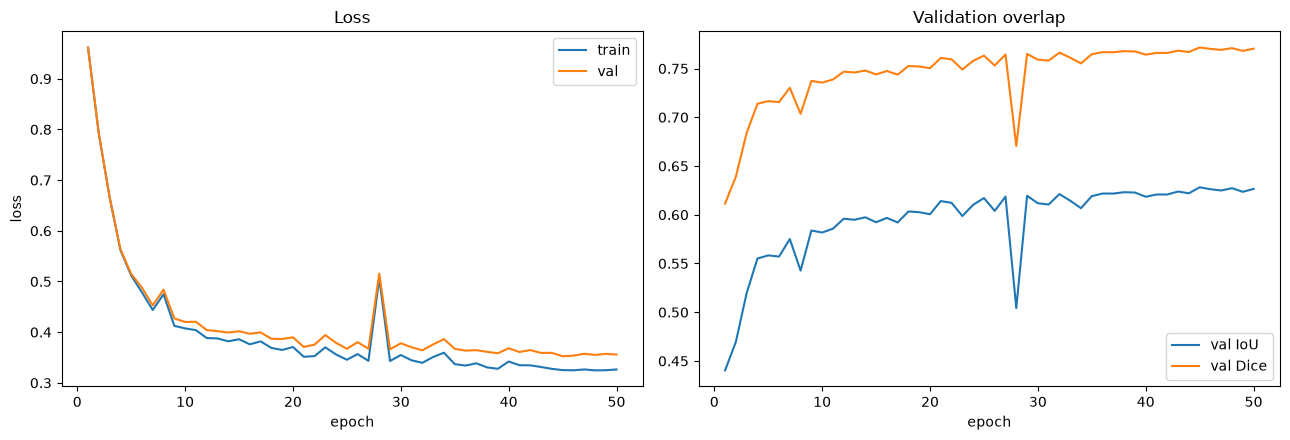

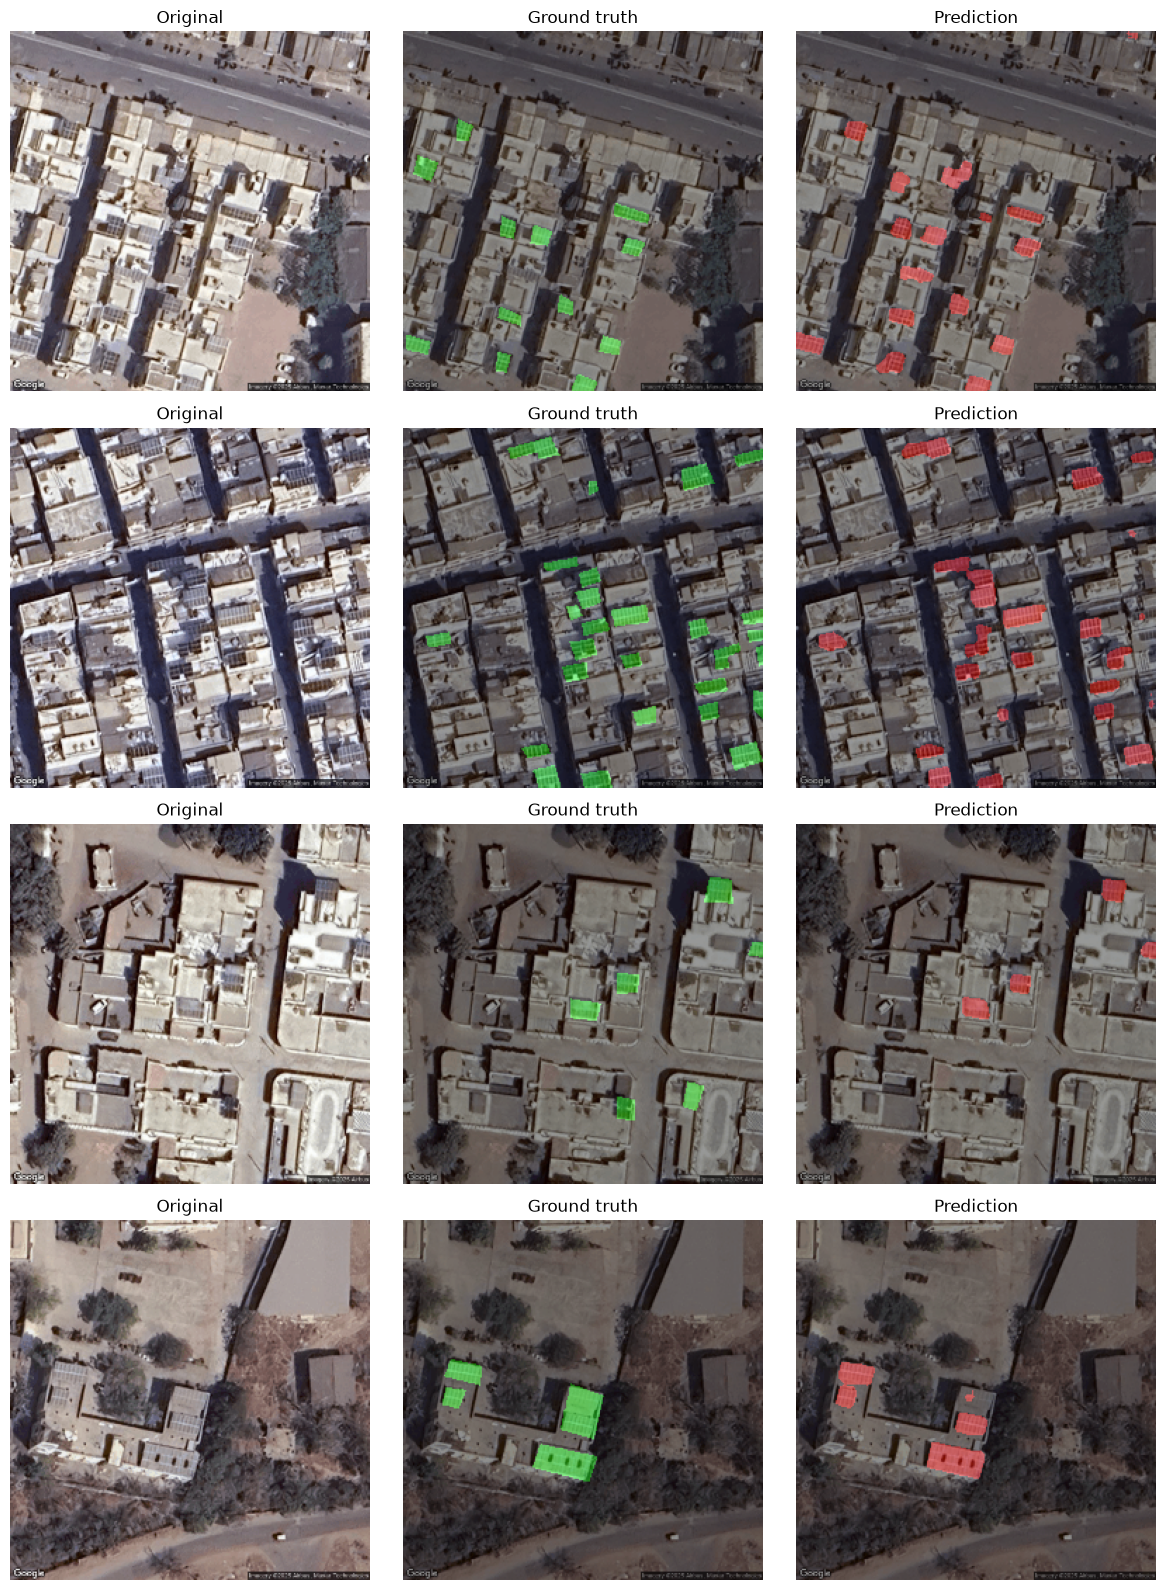

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(history_df["epoch"], history_df["train_loss"], label="train")
ax[0].plot(history_df["epoch"], history_df["val_loss"], label="val")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss"); ax[0].set_title("Loss"); ax[0].legend()

# Fix column names to match your dictionary key names
iou_col = "val_iou" if "val_iou" in history_df.columns else "val_pixel_iou"
dice_col = "val_dice" if "val_dice" in history_df.columns else "val_pixel_dice"

ax[1].plot(history_df["epoch"], history_df[iou_col], label="val IoU")
ax[1].plot(history_df["epoch"], history_df[dice_col], label="val Dice")
ax[1].set_xlabel("epoch"); ax[1].set_title("Validation overlap"); ax[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "training_curves.png"), dpi=150, bbox_inches="tight")
plt.show()

n_show = 4
idxs = np.random.RandomState(SEED).choice(len(test_ds), size=min(n_show, len(test_ds)), replace=False)
fig, axes = plt.subplots(len(idxs), 3, figsize=(12, 4 * len(idxs)))
for r, idx in enumerate(idxs):
    img_t, mask_t, shadow_t = test_ds[idx]
    with torch.no_grad():
        logits = model(img_t.unsqueeze(0).to(DEVICE))
        pred = (F.softmax(logits.float(), dim=1)[0, FOREGROUND_CLASS] > PROB_THRESHOLD).cpu().numpy().astype(np.uint8)

    rgb_i, _ = load_image_and_mask(test_ids[idx])
    rgb_i = cv2.resize(rgb_i, (IMG_SIZE, IMG_SIZE))

    def overlay(base, m, color):
        c = np.zeros_like(base); c[m == 1] = color
        return cv2.addWeighted(base, 0.6, c, 0.4, 0)

    axes[r, 0].imshow(rgb_i); axes[r, 0].set_title("Original"); axes[r, 0].axis("off")
    axes[r, 1].imshow(overlay(rgb_i, mask_t.numpy().astype(np.uint8), (0, 255, 0))); axes[r, 1].set_title("Ground truth"); axes[r, 1].axis("off")
    axes[r, 2].imshow(overlay(rgb_i, pred, (255, 0, 0))); axes[r, 2].set_title("Prediction"); axes[r, 2].axis("off")

    cv2.imwrite(os.path.join(PREDICTIONS_DIR, f"test_{test_ids[idx]}_pred.png"), pred * 255)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "qualitative_examples.png"), dpi=150, bbox_inches="tight")
plt.show()